# Make Data 

In [126]:
import numpy as np
import pandas as pd

np.random.seed(23)
mu_vec1 = np.array([0,0,0])
cov_matrix1 = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

class1sample = np.random.multivariate_normal(mean=mu_vec1,cov = cov_matrix1,size=20)

df = pd.DataFrame(data =class1sample,columns=['feature1','feature2','feature3'])
df['target'] = 1



mu_vec2 = np.array([1,1,1])
cov_matrix2 = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

class2sample = np.random.multivariate_normal(mean=mu_vec2,cov = cov_matrix2,size=20)

df1 = pd.DataFrame(data =class2sample,columns=['feature1','feature2','feature3'])
df1['target'] = 0


In [127]:
df

,feature1,feature2,feature3,target
0,0.666988,0.025813,-0.777619,1
1,0.948634,0.701672,-1.051082,1
2,-0.367548,-1.137460,-1.322148,1
3,1.772258,-0.347459,0.670140,1
4,0.322272,0.060343,-1.043450,1
5,-1.009942,0.441736,1.128877,1
6,-1.838068,-0.938769,-0.201841,1
7,1.045371,0.538162,0.812119,1
8,0.241106,-0.952510,-0.136267,1
9,1.267248,0.173634,-1.223255,1


In [128]:
df1

,feature1,feature2,feature3,target
0,1.250737,0.186384,1.703624,0
1,0.731858,0.517441,2.244610,0
2,1.676860,4.187503,-0.080565,0
3,1.010229,1.437830,2.327788,0
4,0.748855,2.593111,1.170818,0
5,0.290746,0.866975,0.982643,0
6,0.898907,0.435960,0.820964,0
7,2.011059,1.920996,2.933090,0
8,0.204637,-0.011535,3.150780,0
9,1.425140,1.441152,0.182561,0


In [129]:
pd.concat([df,df1])

,feature1,feature2,feature3,target
0,0.666988,0.025813,-0.777619,1
1,0.948634,0.701672,-1.051082,1
2,-0.367548,-1.137460,-1.322148,1
3,1.772258,-0.347459,0.670140,1
4,0.322272,0.060343,-1.043450,1
5,-1.009942,0.441736,1.128877,1
6,-1.838068,-0.938769,-0.201841,1
7,1.045371,0.538162,0.812119,1
8,0.241106,-0.952510,-0.136267,1
9,1.267248,0.173634,-1.223255,1


In [130]:
df = pd.concat([df,df1])
df = df.sample(40)

In [131]:
df

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
14,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1
9,1.425140,1.441152,0.182561,0
11,2.224431,0.230401,1.192120,0
4,0.322272,0.060343,-1.043450,1
12,-0.723253,1.461259,-0.085367,0
13,2.823378,-0.332863,2.637391,0


Now we 3 features 1 Target .            
It is a binary classification problem

Our Target is 3d data ko 2d ma lana ha 

# Visualise it 

In [132]:
import plotly.express as px
px.scatter_3d(
    data_frame=df,
    x = df['feature1'],
    y = df['feature2'],
    z = df['feature3'],
    color=df['target'].astype('str')
)

Now ab huma is 3d data ko 2d ma lana ha .       
Now best possible 2 axes niklana ha 2dimension

# Apply PCA

## 1. Mean centering

In [133]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

## 2. Covarience matrix

In [134]:
covarience_matrix = np.cov([
    df.iloc[:,0],
    df.iloc[:,1],
    df.iloc[:,2],
])
print('Covarience Matrix \n' , covarience_matrix)

Covarience Matrix 
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


## 3. eigen_vectors Eigenvalue

In [135]:
eigen_values,eigen_vector = np.linalg.eig(covarience_matrix)

In [136]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [137]:
eigen_vector

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

# Visualise it

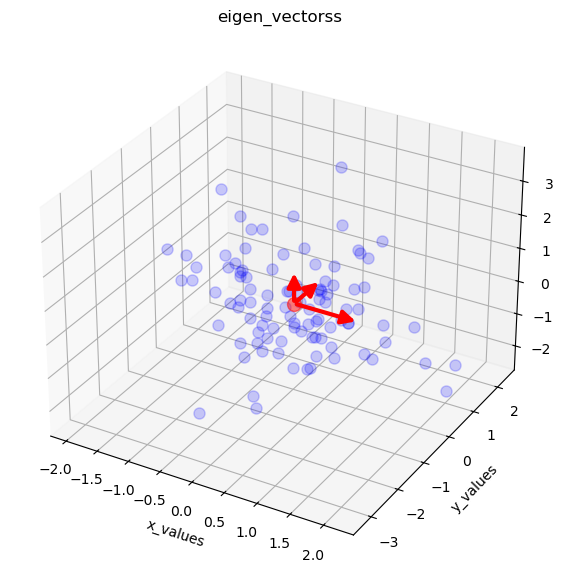

In [138]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

# FIX: Updated Arrow3D class compatible with modern Matplotlib
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        # Use the updated projection matrix from the axes
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)

# Dummy data generation (Replace this with your actual data)
np.random.seed(42)
data = np.random.normal(0, 1, (100, 3))
df = pd.DataFrame(data, columns=['feature1', 'feature2', 'feature3'])
eigen_vector = np.eye(3) # Identity matrix as placeholder eigen_vectorss

# Plotting setup
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Mean values for center positioning
mean_x = df['feature1'].mean()
mean_y = df['feature2'].mean()
mean_z = df['feature3'].mean()

# Plot data points and mean center
ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([mean_x], [mean_y], [mean_z], 'o', markersize=10, color='red', alpha=0.5)

# Render the 3D eigen_vectorss
for v in eigen_vector.T:
    # Notice: v[0], v[1], v[2] added to mean to show direction starting from the mean center
    a = Arrow3D([mean_x, mean_x + v[0]], 
                [mean_y, mean_y + v[1]], 
                [mean_z, mean_z + v[2]], 
                mutation_scale=20, lw=3, arrowstyle="-|>", color="r")
    ax.add_artist(a)

ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')
plt.title('eigen_vectorss')

plt.show()


In [139]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

def plot_3d_eigenvectors(df, eigenvectors):
    """
    Plots 3D data points along with their mean center and eigenvectors using Plotly.
    
    Parameters:
    df (pd.DataFrame): Dataframe with columns 'feature1', 'feature2', 'feature3'
    eigenvectors (np.ndarray): A 3x3 array where columns or rows represent the vectors
    """
    # 1. Calculate mean values for center positioning dynamically
    mean_x = df['feature1'].mean()
    mean_y = df['feature2'].mean()
    mean_z = df['feature3'].mean()

    # 2. Initialize the Plotly figure
    fig = go.Figure()

    # 3. Add the blue dataset points
    fig.add_trace(go.Scatter3d(
        x=df['feature1'], y=df['feature2'], z=df['feature3'],
        mode='markers',
        marker=dict(size=5, color='blue', opacity=0.2),
        name='Data Points'
    ))

    # 4. Add the red center mean point
    fig.add_trace(go.Scatter3d(
        x=[mean_x], y=[mean_y], z=[mean_z],
        mode='markers',
        marker=dict(size=8, color='red', opacity=0.8),
        name='Mean Center'
    ))

    # 5. Add eigenvectors (Lines + Cones for arrowheads)
    for i, v in enumerate(eigenvectors.T):
        # Calculate target endpoints
        target_x = mean_x + v[0]
        target_y = mean_y + v[1]
        target_z = mean_z + v[2]
        
        # Draw the arrow shaft line
        fig.add_trace(go.Scatter3d(
            x=[mean_x, target_x], 
            y=[mean_y, target_y], 
            z=[mean_z, target_z],
            mode='lines',
            line=dict(color='red', width=5),
            showlegend=False
        ))
        
        # Draw the arrow tip using a cone
        fig.add_trace(go.Cone(
            x=[target_x], y=[target_y], z=[target_z], 
            u=[v[0]], v=[v[1]], w=[v[2]],             
            sizemode='absolute',
            sizeref=0.2,                               
            colorscale=[[0, 'red'], [1, 'red']],       
            showscale=False,
            name=f'Eigenvector {i+1}'
        ))

    # 6. Update layout labels and title
    fig.update_layout(
        title='Eigenvectors (Plotly 3D)',
        scene=dict(
            xaxis_title='x_values',
            yaxis_title='y_values',
            zaxis_title='z_values'
        ),
        width=700,
        height=700
    )
    
    return fig


# --- How to call and use the function ---

# Generate sample data
np.random.seed(42)
data = np.random.normal(0, 1, (100, 3))
sample_df = pd.DataFrame(data, columns=['feature1', 'feature2', 'feature3'])
sample_vectors = np.eye(3) 

# Call the function to build the figure
my_plot = plot_3d_eigenvectors(sample_df, sample_vectors)

# Display the interactive plot
my_plot.show()


In [140]:
eigen_vectors = np.array([
    [-0.53875915, -0.69363291,  0.47813384],
    [-0.65608325, -0.01057596, -0.75461442],
    [-0.52848211,  0.72025103,  0.44938304]
    ])

In [141]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [142]:
df.columns

Index(['feature1', 'feature2', 'feature3'], dtype='object')

In [143]:
df

,feature1,feature2,feature3
0,0.496714,-0.138264,0.647689
1,1.523030,-0.234153,-0.234137
2,1.579213,0.767435,-0.469474
3,0.542560,-0.463418,-0.465730
4,0.241962,-1.913280,-1.724918
...,...,...,...
95,-1.952088,-0.151785,0.588317
96,0.280992,-0.622700,-0.208122
97,-0.493001,-0.589365,0.849602
98,0.357015,-0.692910,0.899600


In [147]:
df['target'] = 1

In [148]:
df = pd.concat([df,df1])
df = df.sample(40)
df

,feature1,feature2,feature3,target
16,-1.389866,0.666726,1.343517,0
89,-1.430141,-0.440044,0.130741,1
14,-0.115648,-0.301104,-1.478522,1
3,0.542560,-0.463418,-0.465730,1
33,-0.234587,-1.415371,-0.420645,1
1,1.523030,-0.234153,-0.234137,1
2,1.676860,4.187503,-0.080565,0
1,0.731858,0.517441,2.244610,0
2,1.579213,0.767435,-0.469474,1
0,1.250737,0.186384,1.703624,0


In [149]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df

,PC1,PC2,target
0,0.928721,-0.109021,0
1,1.138243,0.844287,1
2,-0.435769,1.194773,1
3,-0.193549,0.000383,1
4,0.907009,0.486303,1
5,-0.770079,-0.820075,1
6,-3.846534,-1.083651,0
7,0.320015,-2.179448,0
8,-1.607605,-0.689939,1
9,0.011432,-2.108137,0


# 2d pca visualise it

In [ ]:

new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                y=new_df['PC2'],
                color=new_df['target'],
                color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                            line=dict(width=2,
                                        color='DarkSlateGrey')),
                selector=dict(mode='markers'))
fig.show()

hamna snapshot la liya ha data ka covert 3d data to 2d finally using pca